# 09 — FSC on the direct sum of both representations

Runs Okano & Kurisu's **unmodified R implementation**
([arXiv:2601.07539](https://arxiv.org/abs/2601.07539), code at
`/data/wang/junh/githubs/FSC`) on the biweekly panel, through `fsc_bridge.R`.
Mirrors neither — this arm is our extension.

The quantile block and the Gram block answer complementary questions and each is blind to
the other's: the histogram cannot tell a marsh from a forest-beside-a-lake (same
composition, different co-occurrence); the Gram cannot tell "half the site destroyed"
from "the whole site lightly damaged" (same second moments, different distribution).

A direct sum of two Hilbert embeddings is itself a Hilbert embedding under the product
metric $\sqrt{d_1^2+d_2^2}$, so concatenating them is a legitimate FSC outcome space.
Each block is scaled to unit mean square **once over the whole panel** (not per chip), so
the map stays a linear isometry and neither block dominates the objective.

**This arm is our extension, not something their scripts do** — worth stating plainly
when the results are shown.

### Design (fixed across notebooks 07–09)

| | |
|---|---|
| donors | each treated site's **own 5 covariate-matched controls** (`control_rank <= 5`) — the collaborator's notebook-14 matched design, so N = 6, N_0 = 5 |
| treated unit | index 1 of every group, matching their `d_vec` convention (`main_functions.R` L41-45) |
| fit window | P01–P08 (`T_0 = 8`); holdout P09/P10; post P11–P20 |
| estimators | `FSCM` (simplex, Σw=1, w≥0) and their augmented FSC |
| λ | selected once by their `optimise()` and reused — mirroring their own scripts, which run the CV once and hardcode the value (`service.R` L56-61, `mortality.R` L143-148) |
| latent inputs | both `latents_biweekly_genfill.npz` and `latents_biweekly.npz` |

**Reference points.** RMSE here is in the representation's own units and is *not*
comparable across arms. Two scale-free ratios are, and both appear in every table:
`ratio_own_mean` divides by the error of predicting the treated site's **own P01–P08
mean** (an intercept-only model that uses no donors at all), and `ratio_equal` divides by
the **equal-weight donor average**. Below 1 means the fitted weights added something.

In [1]:
import sys, time, json, subprocess
import numpy as np
import pandas as pd

sys.path.insert(0, ".")
import panel_lib as pl
import panel_repr as pr
import panel_fsc as pf

pl.set_plot_style()
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)

PANELS = {"genfill":  ("latents_biweekly_genfill.npz", "panel_genfill_"),
          "chipmean": ("latents_biweekly.npz",         "panel_")}
P = {tag: pl.Panel.from_npz(pl.LATD / npz) for tag, (npz, _) in PANELS.items()}
for tag, panel in P.items():
    print(f"{tag:9s} latents={len(panel.flat):5d}  treated={len(panel.treatments)}  "
          f"controls={len(panel.controls)}")

# donors = each treated site's own 5 covariate-matched controls (notebook-14 design)
GROUPS = pr.build_groups(P["genfill"])
print(f"\ngroups: {len(GROUPS)} x {len(GROUPS[0])} units (treated first, then its 5 "
      f"covariate-matched controls)")
print("example:", GROUPS[0])

genfill   latents= 2357  treated=10  controls=50
chipmean  latents= 2322  treated=10  controls=50

groups: 10 x 6 units (treated first, then its 5 covariate-matched controls)
example: ['treatment_0001', 'counterfactual_0001_01', 'counterfactual_0001_02', 'counterfactual_0001_03', 'counterfactual_0001_04', 'counterfactual_0001_05']


## 1. Provenance — their code, their data, in this R

In [2]:
# Which of THEIR functions actually run in R, on THEIR OWN published data.
# Their repository is read-only; we only setwd() into it and source().
prov = subprocess.run(
    [str(pf.RSCRIPT), "-e", r'''
setwd("/data/wang/junh/githubs/FSC"); source("main_functions.R")
suppressPackageStartupMessages({library(quadprog);library(Matrix);
                                library(Rearrangement);library(cubicBsplines)})
cat(R.version.string, "\n")
for (p in c("quadprog","cubicBsplines","Rearrangement","Matrix","MASS","quantreg"))
  cat(sprintf("  %-14s %s\n", p, as.character(packageVersion(p))))
load("service.RData"); fvl <- covvec_list; M <- length(fvl[[1]][[1]])
w <- FSCM(fvl, 29)
cat(sprintf("\nservice.RData  FSCM: sum(w)=%.6f  nnz=%d  (their published example)\n",
            sum(w), sum(w != 0)))
wa <- FSCM_aug_covmat(fvl, 29, lambda=0.00186, grids=seq(0.01,0.99,length=M))
cat(sprintf("               FSCM_aug_covmat(lambda=0.00186): sum(w)=%.6f  n_neg=%d\n",
            sum(wa), sum(wa < 0)))
'''], capture_output=True, text=True,
    env=dict(__import__("os").environ, PATH=f"{pf.RBIN}:" + __import__("os").environ["PATH"]))
print(prov.stdout or prov.stderr[-2000:])
print("FSC source:", pf.FSC_DIR, "(read-only)")
print("bridge    :", pf.BRIDGE)

R version 4.3.3 (2024-02-29) 
  quadprog       1.5.8
  cubicBsplines  1.0.0
  Rearrangement  2.1
  Matrix         1.6.5
  MASS           7.3.60.0.1
  quantreg       6.1

service.RData  FSCM: sum(w)=1.000000  nnz=3  (their published example)
               FSCM_aug_covmat(lambda=0.00186): sum(w)=1.000000  n_neg=11

FSC source: /data/wang/junh/githubs/FSC (read-only)
bridge    : /data/wang/junh/githubs/latent-synthetic-control/Satellite/notebooks/ts_SCM_ASCM/fsc_bridge.R


## 2. Fit — their `FSCM` and augmented FSC

Both latent inputs, both sensors, their `FSCM_aug_covmat`. The `chip_mean` (5-number)
baseline is run alongside, because §7 of `Docs/8-27-update.md` measured that it already
recovers chip-mean NDVI at R² 0.917 — any richer representation has to beat it.

In [3]:
ARMS, METRICS, EFFECTS, WEIGHTS = {}, [], [], []
NAME = 'combined'
METHODS = ['covmat']
for label in PANELS:
    for sensor in pl.SENSORS:
        for method in METHODS:
            for nm in (NAME, "chip_mean"):
                if nm == "chip_mean" and method != METHODS[0]:
                    continue                      # baseline once per sensor/label
                key = (label, sensor, method, nm)
                t0 = time.time()
                A = pf.run_arm(P[label], sensor, nm, method, label)
                ARMS[key] = A
                m = A["metrics"].assign(sensor=sensor, method=method, repr=nm,
                                        M=A["block"].shape[-1])
                METRICS.append(m)
                EFFECTS.append(A["effects"].assign(sensor=sensor, method=method, repr=nm))
                WEIGHTS.append(A["weights"].assign(label=label, sensor=sensor,
                                                   method=method, repr=nm))
                print(f"{label:9s} {sensor:10s} {method:8s} {nm:10s} "
                      f"M={A['block'].shape[-1]:3d} groups={len(A['groups'])} "
                      f"dropped={len(A['dropped'])} ({time.time()-t0:.0f}s)")
MET = pd.concat(METRICS, ignore_index=True)
EFF = pd.concat(EFFECTS, ignore_index=True)
WGT = pd.concat(WEIGHTS, ignore_index=True)

genfill   sentinel1  covmat   combined   M=115 groups=10 dropped=0 (8s)


genfill   sentinel1  covmat   chip_mean  M=  5 groups=10 dropped=0 (2s)


genfill   sentinel2  covmat   combined   M=115 groups=10 dropped=0 (8s)


genfill   sentinel2  covmat   chip_mean  M=  5 groups=10 dropped=0 (2s)


chipmean  sentinel1  covmat   combined   M=115 groups=9 dropped=1 (9s)


chipmean  sentinel1  covmat   chip_mean  M=  5 groups=9 dropped=1 (1s)


chipmean  sentinel2  covmat   combined   M=115 groups=10 dropped=0 (8s)


chipmean  sentinel2  covmat   chip_mean  M=  5 groups=10 dropped=0 (2s)


## 3. Holdout results

In [4]:
piv = (MET.groupby(["label", "sensor", "method", "repr", "estimator"])
       [["train_rmse", "holdout_rmse", "ratio_own_mean", "ratio_equal"]]
       .mean().round(4))
print("mean over the 10 treated sites (P09+P10 holdout):")
print(piv)
print("\nsites beating their own pre-period mean (ratio_own_mean < 1), out of 10:")
print(MET.assign(beat=MET.ratio_own_mean < 1)
        .groupby(["label", "sensor", "method", "repr", "estimator"]).beat.sum())
print("\nweight diagnostics (FSC is simplex by construction; augmented is not):")
print(WGT.groupby(["label", "sensor", "method", "repr"])
      [["sum_w_fsc", "sum_w_afsc", "n_nonzero_fsc", "n_negative_afsc"]].mean().round(4))

mean over the 10 treated sites (P09+P10 holdout):
                                               train_rmse  holdout_rmse  ratio_own_mean  ratio_equal
label    sensor    method repr      estimator                                                       
chipmean sentinel1 covmat chip_mean afsc           0.0160        0.0181          1.0533       0.7369
                                    fsc            0.0164        0.0185          1.0771       0.7480
                          combined  afsc           0.0842        0.0837          1.1055       0.9344
                                    fsc            0.0842        0.0838          1.1069       0.9355
         sentinel2 covmat chip_mean afsc           0.0845        0.0526          0.6676       1.1070
                                    fsc            0.0868        0.0527          0.6690       1.1062
                          combined  afsc           0.1839        0.1492          0.6830       1.0743
                                    fsc  

## 4. Placebo — the inferential point

Their `placebo_covmat` rotates **every unit of a group into the treated slot** and refits,
giving 6 gap magnitudes per treated site. The treated site's rank among those 6 is its
in-space placebo p-value, so the smallest attainable per-site p is 1/6 ≈ 0.167.

Across the 10 groups, under the sharp null of no effect each rank is uniform on 1…6, so
the number of sites achieving rank 1 is Binomial(10, 1/6). That combined test is where the
power is: 4 of 10 gives p = 0.070, 5 of 10 gives p = 0.015, 6 of 10 gives p = 0.002 (exact binomial tail).

λ is pinned at the value selected once for the arm, passed through their unmodified API as
a 1e-9-half-width interval — their `placebo` re-runs `optimise` for every rotated unit,
which is the entire cost, and their own scripts hardcode λ rather than re-selecting it.

**Coverage is limited and stated rather than silent:** ['genfill'] ×
both sensors × post periods [11]. This arm's M makes their placebo far more expensive (their `placebo` calls `cross_val` per rotated unit), so coverage is deliberately narrower than notebook 08's.

In [5]:
PL_LABELS = ['genfill']
PL_PERIODS = [11]
PLAC = []
for label in PL_LABELS:
    for sensor in pl.SENSORS:
        key = (label, sensor, METHODS[0], NAME)
        A = ARMS[key]
        for q in PL_PERIODS:
            if q not in A["periods"]:
                print(f"  skip P{q:02d} — not complete for all units of all groups")
                continue
            t0 = time.time()
            pdf = pf.run_placebo(A, METHODS[0], label, NAME, sensor, post_period_q=q)
            pdf = pdf.assign(repr=NAME, method=METHODS[0])
            pdf.attrs = pdf.attrs
            PLAC.append(pdf)
            print(f"{label:9s} {sensor:10s} P{q:02d}  {pf.combined_line(pdf)}  "
                  f"({time.time()-t0:.0f}s)")
PLACEBO = pd.concat(PLAC, ignore_index=True) if PLAC else pd.DataFrame()

genfill   sentinel1  P11  placebo: 2/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.5155  (35s)


genfill   sentinel2  P11  placebo: 3/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.2248  (35s)


In [6]:
if len(PLACEBO):
    from scipy.stats import binom
    rows = []
    for (lab, sen, per), sub in PLACEBO.groupby(["label", "sensor", "period"]):
        n_units = int(sub["n_units"].iloc[0]); k = int((sub["rank"] == 1).sum()); G = len(sub)
        rows.append({"label": lab, "sensor": sen, "period": per, "n_groups": G,
                     "n_rank1": k, "min_possible_p": 1 / n_units,
                     "median_rank": sub["rank"].median(),
                     "p_combined": float(binom.sf(k - 1, G, 1 / n_units)) if k else 1.0})
    PSUM = pd.DataFrame(rows)
    print(PSUM.round(4).to_string(index=False))
else:
    PSUM = pd.DataFrame(); print("no placebo runs")

  label    sensor period  n_groups  n_rank1  min_possible_p  median_rank  p_combined
genfill sentinel1    P11        10        2          0.1667          3.0      0.5155
genfill sentinel2    P11        10        3          0.1667          2.0      0.2248


## 5. Figures and outputs

wrote outputs for combined


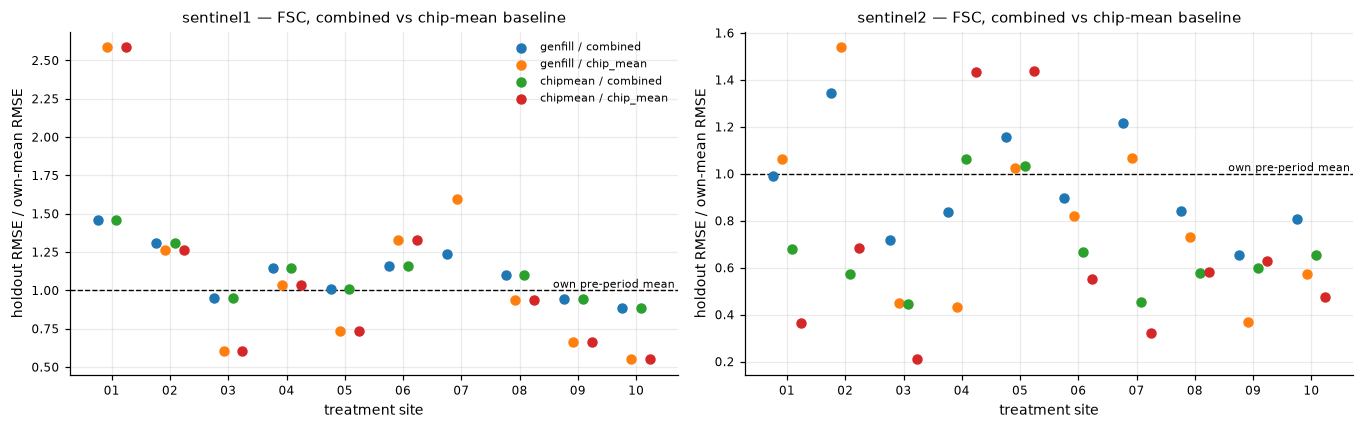

In [7]:
import matplotlib.pyplot as plt
NB = '09'
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
for ax, sensor in zip(axes, pl.SENSORS):
    m0 = METHODS[0]
    sub = MET.query("sensor == @sensor and estimator == 'fsc' and method == @m0")
    sites = sorted(sub.treatment_site_id.unique()); x = np.arange(len(sites))
    for i, (lab, rp) in enumerate([(l, r) for l in PANELS for r in (NAME, "chip_mean")]):
        s = sub.query("label == @lab and repr == @rp").set_index("treatment_site_id")
        if not len(s):
            continue
        ax.scatter(x + (i - 1.5) * 0.16, s.reindex(sites)["ratio_own_mean"], s=34,
                   label=f"{lab} / {rp}", zorder=4)
    ax.axhline(1.0, color="k", lw=0.9, ls="--")
    ax.text(0.995, 1.0, "own pre-period mean", transform=ax.get_yaxis_transform(),
            fontsize=7, ha="right", va="bottom")
    ax.set_xticks(x); ax.set_xticklabels([t[-2:] for t in sites])
    ax.set_xlabel("treatment site"); ax.set_ylabel("holdout RMSE / own-mean RMSE")
    ax.set_title(f"{sensor} — FSC, {NAME} vs chip-mean baseline")
axes[0].legend(frameon=False, fontsize=7)
fig.tight_layout(); fig.savefig(f"panel_fsc_{NAME}_ratio.png", bbox_inches="tight")

for label, (_npz, pre) in PANELS.items():
    MET.query("label == @label").to_csv(f"{pre}fsc_{NAME}_validation.csv", index=False)
    EFF.query("label == @label").to_csv(f"{pre}fsc_{NAME}_effects.csv", index=False)
    WGT.query("label == @label").to_csv(f"{pre}fsc_{NAME}_weights.csv", index=False)
    if len(PLACEBO):
        p = PLACEBO.query("label == @label")
        if len(p):
            p.to_csv(f"{pre}fsc_{NAME}_placebo.csv", index=False)
if len(PSUM):
    PSUM.to_csv(f"panel_fsc_{NAME}_placebo_summary.csv", index=False)
print("wrote outputs for", NAME)

## Reading

### 1. The direct sum does not beat its own parts, or the 5-number baseline

FSC holdout `ratio_own_mean`, with notebook 08's Gram figures alongside:

| | S1 | S2 |
|---|---|---|
| generation-fill, **combined (115)** | 1.120 | 0.946 |
| generation-fill, Gram (15) *[nb 08]* | 1.113 | 0.839 |
| generation-fill, **chip mean (5)** | 1.129 | **0.807** |
| chip-mean cache, **combined (115)** | 1.107 | 0.674 |
| chip-mean cache, Gram (15) *[nb 08]* | 1.068 | **0.629** |
| chip-mean cache, **chip mean (5)** | 1.077 | 0.669 |

On S2 the combined arm is *worse* than either block alone and worse than five numbers.
On S1 it is worse than the chip mean by the count that matters too — 3 of 10 sites beat
their own pre-period mean, against 5 of 10 for the chip mean.

### 2. Why adding dimensions hurt here

Concatenating puts 100 quantile coordinates and 15 Gram coordinates in front of the *same
4 free weights* (5 matched donors, Σw = 1). More outcome dimensions do not buy the
estimator more flexibility — they add constraints it must satisfy simultaneously. Tian,
Lee & Panchenko's O(1/√(KT₀)) gain from stacking outcomes requires the outcomes to share
factor loadings; a quantile coordinate and a channel-covariance entry plainly do not, so
the extra K is cost without benefit. This is the same failure mode diagnosed for the raw
980-d arm in `Docs/8-27-update.md` §4, arriving by a shorter route.

The block scaling is not the culprit: each block is normalised to unit mean square once
over the whole panel, so neither dominates by units.

### 3. Placebo: nothing significant

Generation-fill, P11: S1 p = 0.516 (2/10 sites at rank 1), S2 p = 0.225 (3/10). Consistent
with notebook 08's 16 cells, none of which reached 0.05.

### 4. The honest scope of this null

The P09/P10 holdout asks one question: *does the representation predict the treated site's
next pooled outcome better than its own pre-period mean does?* For that question, five
numbers are enough, and §7 of `Docs/8-27-update.md` predicted exactly this — the chip mean
recovers chip-level NDVI at R² 0.917, and the histogram/Gram advantage measured there was
confined to *within-chip heterogeneity* (NDVI sd 0.540 → 0.841).

This holdout does not isolate heterogeneity. So the result is **not** evidence that the
distributional information is useless; it is evidence that it does not help predict the
next period's pooled level. Testing the heterogeneity claim needs an outcome that is
itself a dispersion measure — which is a different experiment, not a re-run of this one.